In [2]:
from nba_api.stats.endpoints import LeagueGameLog

In [3]:
gamelog = LeagueGameLog(
  season = "2024-25"
)

In [4]:
gamelog

In [5]:
games = gamelog.get_data_frames()[0]

In [6]:
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22024,1610612738,BOS,Boston Celtics,0022400061,2024-10-22,BOS vs. NYK,W,240,48,...,29,40,33,6,3,4,15,132,23,1
1,22024,1610612750,MIN,Minnesota Timberwolves,0022400062,2024-10-22,MIN @ LAL,L,240,35,...,35,47,17,4,1,16,22,103,-7,1
2,22024,1610612747,LAL,Los Angeles Lakers,0022400062,2024-10-22,LAL vs. MIN,W,240,42,...,31,46,22,7,8,7,22,110,7,1
3,22024,1610612752,NYK,New York Knicks,0022400061,2024-10-22,NYK @ BOS,L,240,43,...,29,34,20,2,3,12,12,109,-23,1
4,22024,1610612744,GSW,Golden State Warriors,0022400072,2024-10-23,GSW @ POR,W,240,48,...,42,57,38,13,5,18,27,140,36,1


In [7]:
thunder = games[games["TEAM_ABBREVIATION"] == "OKC"]

In [8]:
thunder.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
24,22024,1610612760,OKC,Oklahoma City Thunder,0022400075,2024-10-24,OKC @ DEN,W,240,43,...,36,49,23,9,13,12,15,102,15,1
58,22024,1610612760,OKC,Oklahoma City Thunder,0022400091,2024-10-26,OKC @ CHI,W,240,45,...,45,54,21,15,5,10,18,114,19,1
79,22024,1610612760,OKC,Oklahoma City Thunder,0022400100,2024-10-27,OKC vs. ATL,W,240,44,...,34,45,26,13,12,10,23,128,24,1
130,22024,1610612760,OKC,Oklahoma City Thunder,0022400125,2024-10-30,OKC vs. SAS,W,240,41,...,34,39,28,18,6,14,15,105,12,1
147,22024,1610612760,OKC,Oklahoma City Thunder,0022400140,2024-11-01,OKC @ POR,W,240,51,...,31,45,31,14,9,13,29,137,23,1


In [9]:
len(thunder)

82

In [10]:
thunder_win = thunder[thunder["WL"] == "W"]
thunder_lose = thunder[thunder["WL"] == "L"]

In [15]:
thunder_win_TOV = thunder_win["TOV"].mean()
thunder_lose_TOV = thunder_lose["TOV"].mean()

In [16]:
print(thunder_win_TOV)
print(thunder_lose_TOV)

11.735294117647058
11.642857142857142


Matplotlib is building the font cache; this may take a moment.


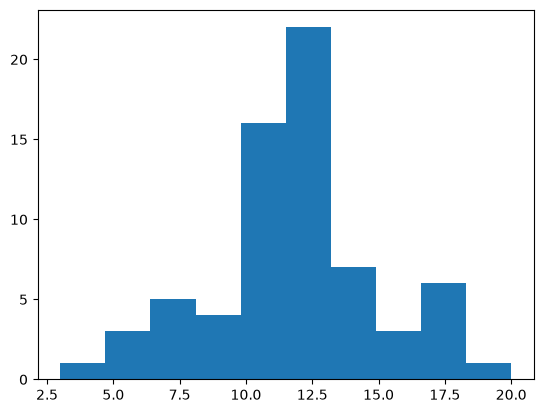

In [17]:
import matplotlib.pyplot as plt

plt.hist(thunder_win["TOV"])
plt.show()

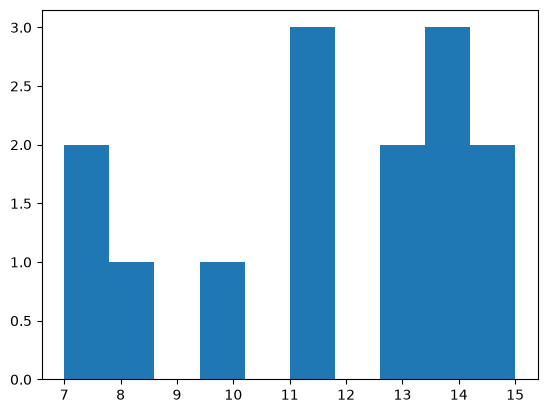

In [18]:
plt.hist(thunder_lose["TOV"])
plt.show()

Text(0.5, 1.0, 'Turnovers: Win vs Lose')

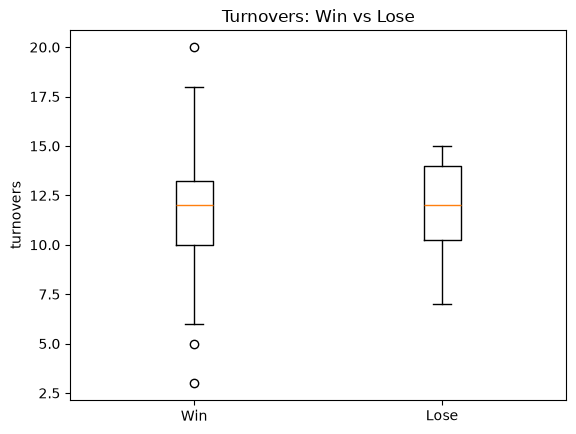

In [19]:
plt.boxplot(
  [thunder_win["TOV"], thunder_lose["TOV"]],
  tick_labels=["Win", "Lose"]
)

plt.ylabel("turnovers")
plt.title("Turnovers: Win vs Lose")

In [20]:
thunder.columns

Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M',
       'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST',
       'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE'],
      dtype='str')

In [21]:
stats = ["FG_PCT", "FG3_PCT", "REB", "AST", "TOV"]

In [22]:
for stat in stats:
  print(stat)
  print(f"Win : {thunder_win[stat].mean():.3f}")
  print(f"Lose : {thunder_lose[stat].mean():.3f}")
  print("-----------------------------")

FG_PCT
Win : 0.489
Lose : 0.448
-----------------------------
FG3_PCT
Win : 0.380
Lose : 0.341
-----------------------------
REB
Win : 45.426
Lose : 41.643
-----------------------------
AST
Win : 26.971
Lose : 26.286
-----------------------------
TOV
Win : 11.735
Lose : 11.643
-----------------------------


In [24]:
from scipy.stats import ttest_ind

In [25]:
ttest_ind(
  thunder_win["FG_PCT"],
  thunder_lose["FG_PCT"]
)

TtestResult(statistic=np.float64(3.3546499508917047), pvalue=np.float64(0.0012169365646290922), df=np.float64(80.0))

In [33]:
for stat in stats:
    result = ttest_ind(
    thunder_win[stat],
    thunder_lose[stat]
  )

    print(f"{stat}")
    print(f"t値 : {result.statistic:.3f}")
    print(f"p値 : {result.pvalue:.3f}")
    print("----------------------------------")

FG_PCT
t値 : 3.355
p値 : 0.001
----------------------------------
FG3_PCT
t値 : 1.669
p値 : 0.099
----------------------------------
REB
t値 : 1.836
p値 : 0.070
----------------------------------
AST
t値 : 0.447
p値 : 0.656
----------------------------------
TOV
t値 : 0.099
p値 : 0.921
----------------------------------


In [34]:
thunder["WL_NUM"] = thunder["WL"].map({
  "W" : 1,
  "L" : 0
})

In [35]:
thunder.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE,WL_NUM
24,22024,1610612760,OKC,Oklahoma City Thunder,0022400075,2024-10-24,OKC @ DEN,W,240,43,...,49,23,9,13,12,15,102,15,1,1
58,22024,1610612760,OKC,Oklahoma City Thunder,0022400091,2024-10-26,OKC @ CHI,W,240,45,...,54,21,15,5,10,18,114,19,1,1
79,22024,1610612760,OKC,Oklahoma City Thunder,0022400100,2024-10-27,OKC vs. ATL,W,240,44,...,45,26,13,12,10,23,128,24,1,1
130,22024,1610612760,OKC,Oklahoma City Thunder,0022400125,2024-10-30,OKC vs. SAS,W,240,41,...,39,28,18,6,14,15,105,12,1,1
147,22024,1610612760,OKC,Oklahoma City Thunder,0022400140,2024-11-01,OKC @ POR,W,240,51,...,45,31,14,9,13,29,137,23,1,1


In [36]:
features = [
  "FG_PCT",
  "FG3_PCT",
  "REB",
  "AST",
  "TOV"
]

In [37]:
X = thunder[features]

In [38]:
X.head()

,FG_PCT,FG3_PCT,REB,AST,TOV
24,0.426,0.222,49,23,12
58,0.421,0.200,54,21,10
79,0.494,0.400,45,26,10
130,0.461,0.415,39,28,14
147,0.537,0.388,45,31,13


In [39]:
y = thunder["WL_NUM"]

In [42]:
y.head()

24     1
58     1
79     1
130    1
147    1
Name: WL_NUM, dtype: int64

In [43]:
y.value_counts()

WL_NUM
1    68
0    14
Name: count, dtype: int64

In [46]:
import sklearn

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size = 0.2,
  random_state=42,
  stratify=y
)

In [81]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(65, 5)
(17, 5)
(65,)
(17,)


In [82]:
model = RandomForestClassifier(
  random_state=42,
  class_weight = "balanced"
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [83]:
print("training set score: {:.2f}".format(model.score(X_train, y_train)))
print("test set score: {:.2f}".format(model.score(X_test, y_test)))

training set score: 0.98
test set score: 0.59


In [84]:
importance = model.feature_importances_

for feature, score in zip(features, importance):
  print(f"{feature:<8} : {score:.2f}")

FG_PCT   : 0.31
FG3_PCT  : 0.25
REB      : 0.24
AST      : 0.09
TOV      : 0.10


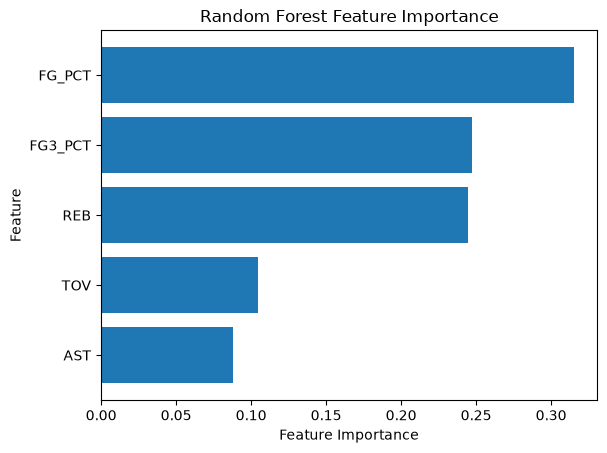

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
  "Feature": features,
  "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
  "Importance",
  ascending=True
)

plt.barh(
  importance_df["Feature"],
  importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.savefig("../images/feature_importance.png", dpi =300, bbox_inches="tight")

plt.show()

In [86]:
y_pred = model.predict(X_test)

In [90]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 2]
 [5 9]]


In [91]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.17      0.33      0.22         3
           1       0.82      0.64      0.72        14

    accuracy                           0.59        17
   macro avg       0.49      0.49      0.47        17
weighted avg       0.70      0.59      0.63        17



In [92]:
from sklearn.model_selection import cross_validate

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1"
]

cv_result = cross_validate(
    model,
    X,
    y,
    cv=5,
    scoring=scoring
)

for score in scoring:
    print(f"{score} : {cv_result['test_' + score].mean():.3f}")

accuracy : 0.734
precision : 0.865
recall : 0.812
f1 : 0.827
